## 案例: 演示 CART 分类回归决策树的 分类功能.

#### 导包

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.preprocessing import StandardScaler        # 特征处理

#### 1. 加载数据

In [2]:
data = pd.read_csv('./data/train.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


#### 2. 数据的预处理

In [10]:
# 2.1 提取特征和标签
x = data[['Pclass', 'Sex', 'Age']]
y = data['Survived']
print(x.head(5))
print(y.head(5))

# 2.2 发现Age列有缺失，用该列的平均值填充
# x['Age'].fillna(x['Age'].mean(), inplace=True)    # 会报警告，但是可以用
# x['Age'] = x['Age'].fillna(x['Age'].mean())       # 会报警告，因为是直接修改源数据的

# 解决方案
x = x.copy()
x['Age'] = x['Age'].fillna(x['Age'].mean())

# 2.3 查看处理后的数据集
print(x.info())

# 2.4 针对于Sex列，进行one-hot编码
x = pd.get_dummies(x, columns=['Sex'])
x.drop(['Sex_male'], axis=1, inplace=True)
x.info()

# 2.5 划分训练集和测试集
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=23)

   Pclass     Sex   Age
0       3    male  22.0
1       1  female  38.0
2       3  female  26.0
3       1  female  35.0
4       3    male  35.0
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Pclass  891 non-null    int64  
 1   Sex     891 non-null    object 
 2   Age     891 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 21.0+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      891 non-null    int64  
 1   Age         891 non-null    float64
 2   Sex_female  891 non-null    bool   
dtypes: bool(1), float64(1), int64(1)
memory usage: 14.9 KB


#### 3. 特征工程

In [13]:
# 3.1 创建 标准化对象.
transfer = StandardScaler()
# 3.2 对训练集和测试集进行标准化处理.
x_train = transfer.fit_transform(x_train)
x_test = transfer.transform(x_test)

#### 4. 模型训练

In [14]:
# 参数：max_depth=10   意思是：绘制的决策树结构，最多10曾
estimator = DecisionTreeClassifier(max_depth=10)
estimator.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### 5. 模型预测

In [15]:
y_pred = estimator.predict(x_test)
print(f'预测值为：{y_pred}')

预测值为：[1 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 1 0 0 0 1 0 0 0 0 0 1 0 1 1 0 1 0 1 0 1 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 1
 0 0 1 0 1 1 0 1 1 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0
 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 1 1 0 0 1 0 0 0 1 1 0 0 0 1 1 1 1 1 0 0 0
 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 1 1]


#### 6.模型评估

In [16]:
print(f'分类评估报告：\n{classification_report(y_test, y_pred)}')

分类评估报告：
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       115
           1       0.74      0.61      0.67        64

    accuracy                           0.78       179
   macro avg       0.77      0.74      0.75       179
weighted avg       0.78      0.78      0.78       179



#### 7. 绘制决策树图

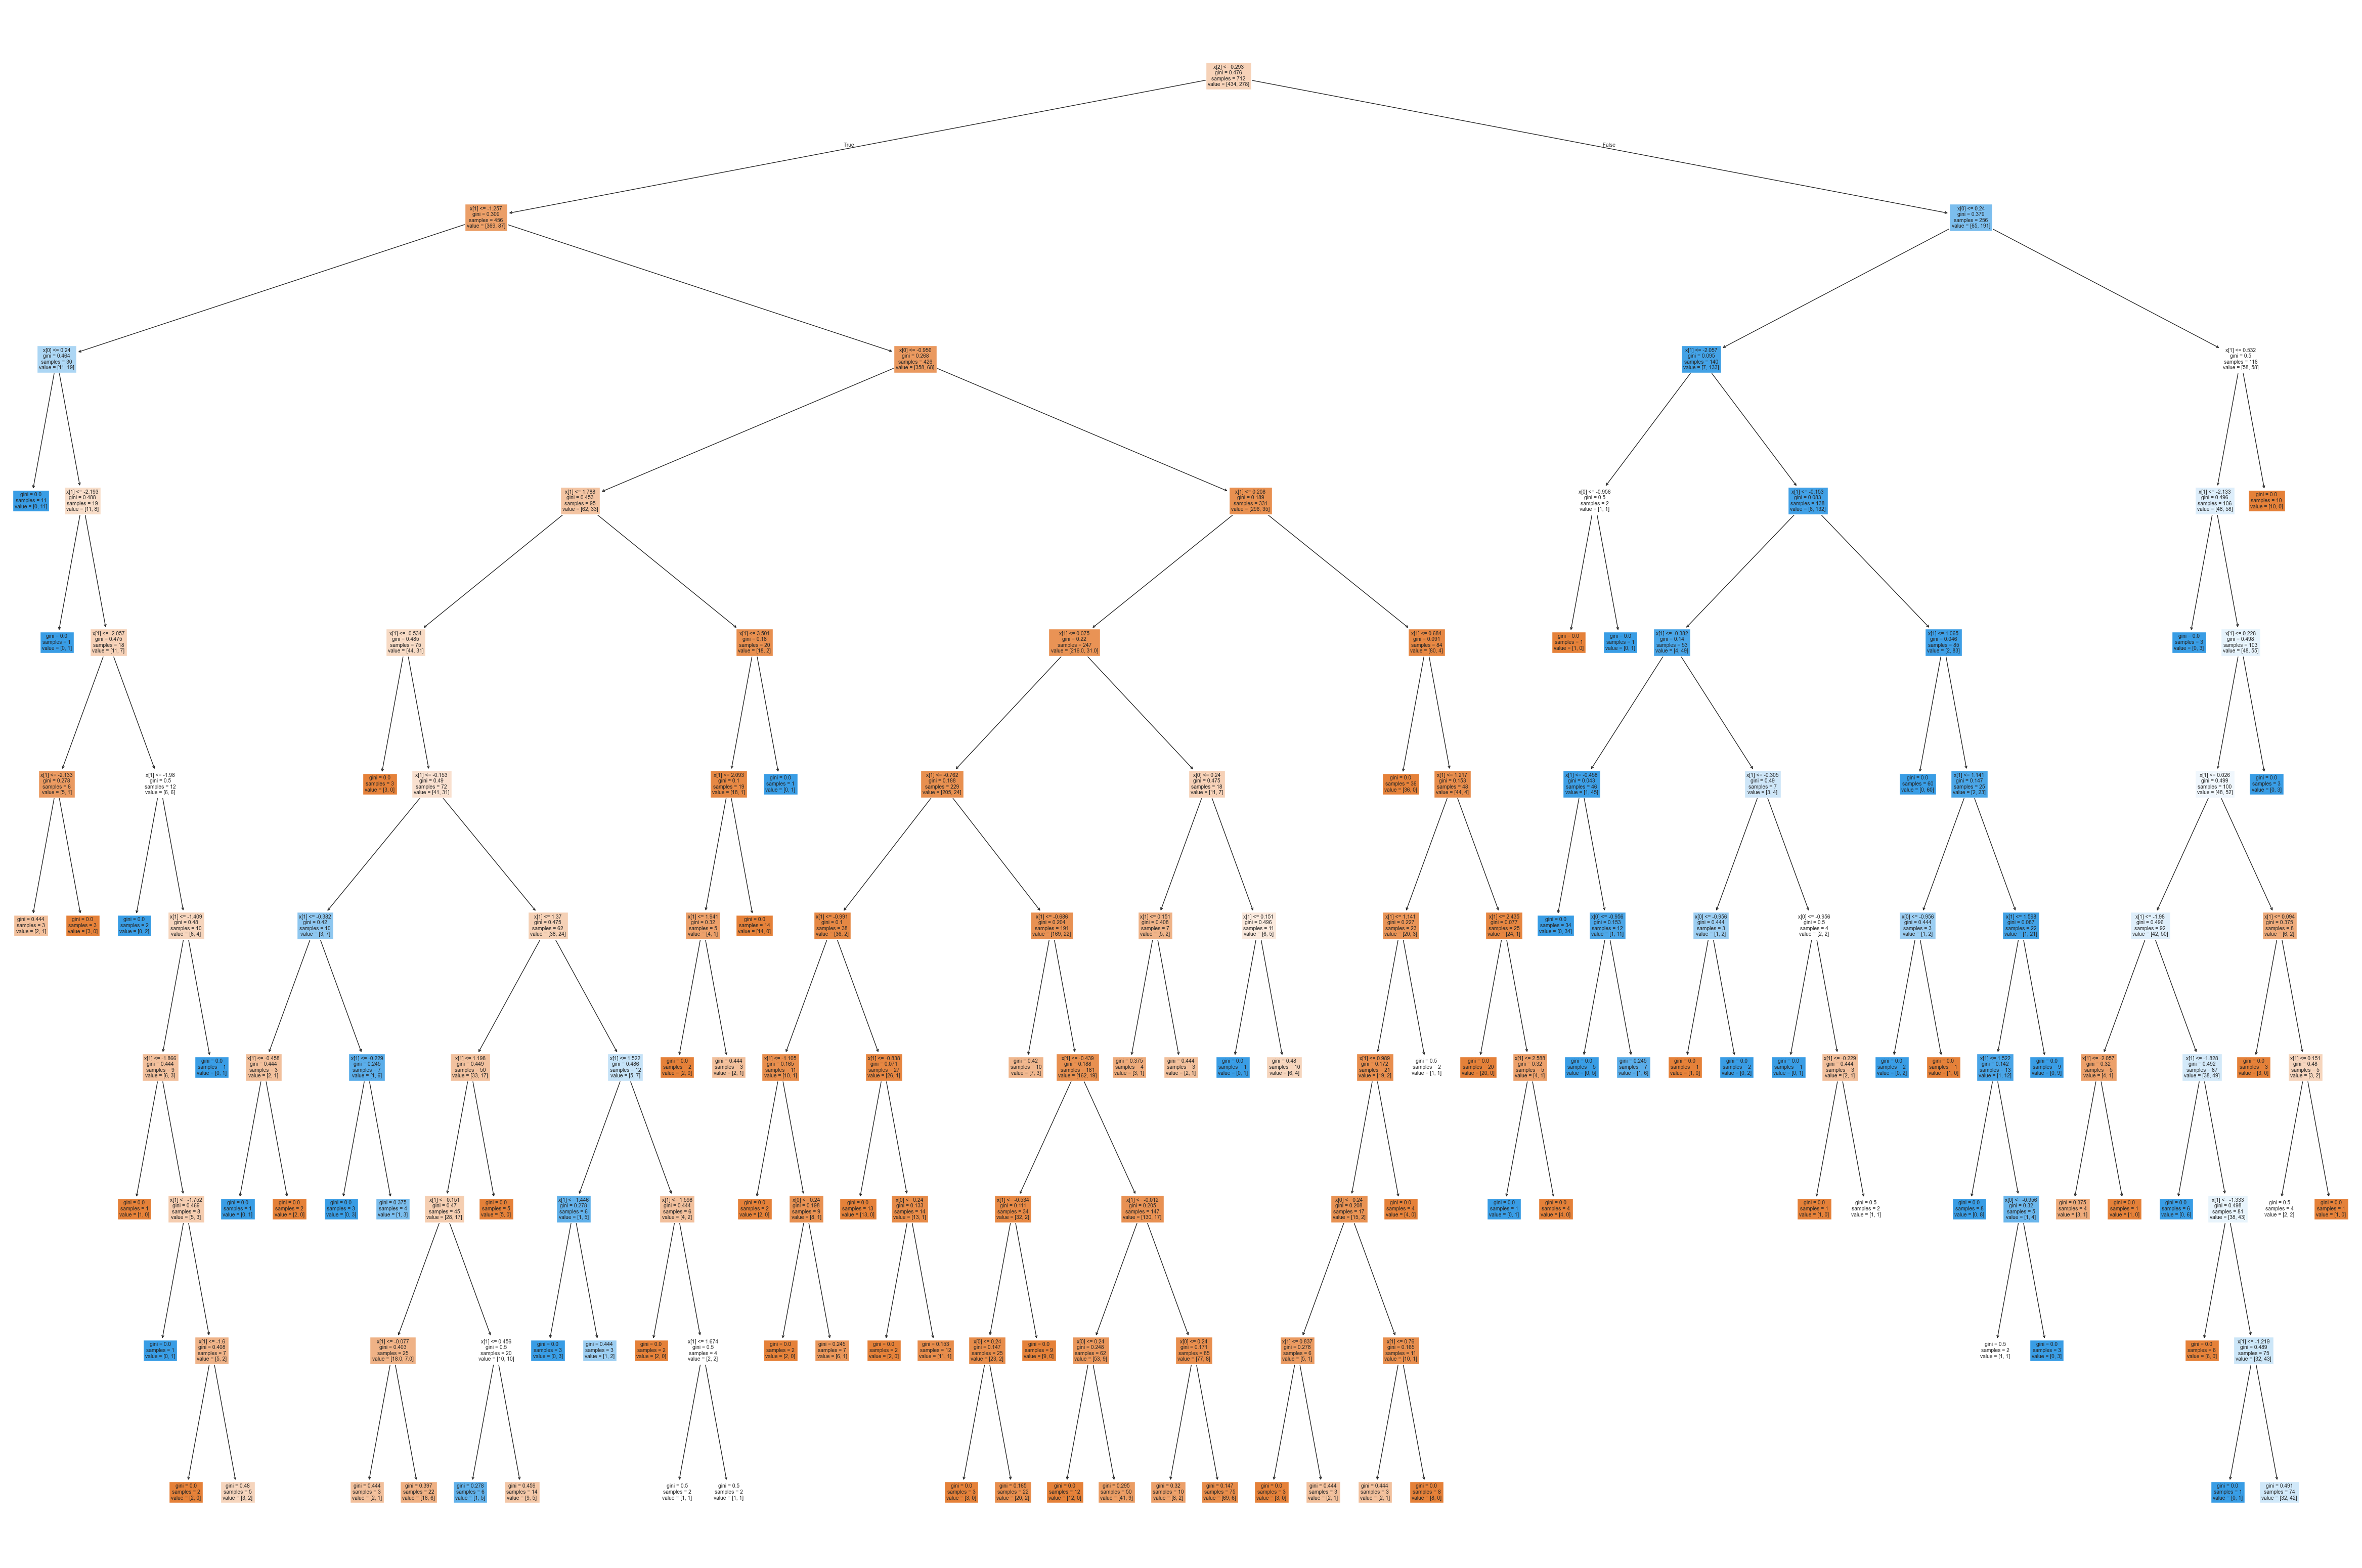

In [18]:
plt.figure(figsize=(60, 40))
# 参1：模型对象    参2：是否用颜色填充    参3：绘制的决策树结构，最多10层
plot_tree(estimator, filled=True, max_depth=10)
plt.savefig('./data/my_titanic.png')
plt.show()